(example_5)=
# Example 5: Learning causal coupling in a simple control task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ilabcode/pyhgf/blob/master/docs/source/notebooks/Example_3_Multi_armed_bandit.ipynb)

```{admonition} Authors
:class: tip

- Lina Walkowiak, Aarhus University, Denmark ([202205493@post.au.dk](202205493@post.au.dk))
- Nicolas Legrand, Aarhus University, Denmark ([nicolas.legrand@cas.au.dk](nicolas.legrand@cas.au.dk))
```

In [1]:
import sys

from IPython.utils import io

if 'google.colab' in sys.modules:

  with io.capture_output() as captured:
      ! pip install pyhgf watermark

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial
from typing import Callable, Dict, NamedTuple, Optional, Tuple

import jax
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
from jax import Array, jit
from sklearn.metrics import mutual_info_score
from matplotlib import rcParams

from pyhgf import load_data
from pyhgf.math import gaussian_surprise, sigmoid, gaussian_density
from pyhgf.response import first_level_gaussian_surprise
from pyhgf.model.network import Network
from pyhgf.typing import Edges
from pyhgf.utils import beliefs_propagation
from pyhgf.updates.prediction_error.continuous import continuous_node_prediction_error
from pyhgf.updates.posterior.continuous import continuous_node_posterior_update
from pyhgf.updates.prediction.continuous import continuous_node_prediction


np.random.seed(123)
plt.rcParams["figure.constrained_layout.use"] = True

# Introduction
In this notebook, we implement the mechanism outlined in the predictive coding causal discovery notebook in a simple control task. 


In [3]:
def prediction_error(u, alpha, mu_1, mu_2, var_1, var_2):
    return (u - mu_2 - alpha * mu_1)**2 * (1 / (alpha**2 * var_1 + var_2 ) )

In [4]:
def find_alpha(u, mu_1, mu_2, var_1, var_2):

    # find root 1
    alpha_hat_1 = jnp.where(mu_1 == 0.0, 0.0, - (mu_2 - u) / mu_1)

    # find root 2
    alpha_hat_2 = jnp.where((mu_2 - u) == 0.0, 0.0, (mu_1 * var_2) / ((mu_2 - u) * var_1))

    # evaluate at 0, 1 and the two possible roots
    candidates = jnp.array([0.0, alpha_hat_1, alpha_hat_2, 1.0])
    candidates = jnp.where((candidates >= 0.0) & (candidates <= 1.0), candidates, 0.0)

    pe = prediction_error(u, candidates, mu_1, mu_2, var_1, var_2)
    
    return candidates[jnp.argmin(pe)]

In [5]:
@partial(jit, static_argnames=("node_idx", "edges"))
def continuous_node_causal_strength(
    attributes: Dict,
    edges: Edges,
    node_idx: int,
) -> Array:
    r"""Update the causal strength between this node and all causal children.

    Parameters
    ----------
    attributes :
        The attributes of the probabilistic nodes.
    node_idx :
        Pointer to the value parent node that will be updated.

    Returns
    -------
    attributes :
        The attributes of the probabilistic nodes.

    """
    # get the expected mean and precision from the causal parent
    parent_expected_mean = attributes[node_idx]["expected_mean"]
    parent_expected_precision = attributes[node_idx]["expected_precision"]

    # set a learning rate for the speed of updating
    learning_rate = 0.1

    # for all causal children, compute the new causal strength
    new_strengths = []
    for causal_child_idx, strength in zip(
        edges[node_idx].causal_children,
        attributes[node_idx]["causal_coupling_children"],
    ):

        # get children's expected mean and precision
        child_expected_mean = attributes[causal_child_idx]["expected_mean"]
        child_expected_precision = attributes[causal_child_idx]["expected_precision"]

        # get a new estimate of alpha
        new_alpha = find_alpha(
            u=attributes[causal_child_idx]["mean"], 
            mu_1=parent_expected_mean,
            mu_2=child_expected_mean, 
            var_1=1 / parent_expected_precision, 
            var_2=1 / child_expected_precision,
        )

        new_strengths.append(strength + (new_alpha - strength) * learning_rate)

    # update the strengths vector
    attributes[node_idx]["causal_coupling_children"] = jnp.array(new_strengths)

    return attributes

# Simualtion: Optimal control in a simple ball-beam problem
We simulate agents that act in a dynamic environment, where the goal is to balance a variable (eg. a ball)) at 0, counteracting the randomly evolving position of it. 

We define an array of varying causal influences that are determining the extend to which the agent's action will influence the ball's position. This is what the causal agent is trying to infer. 

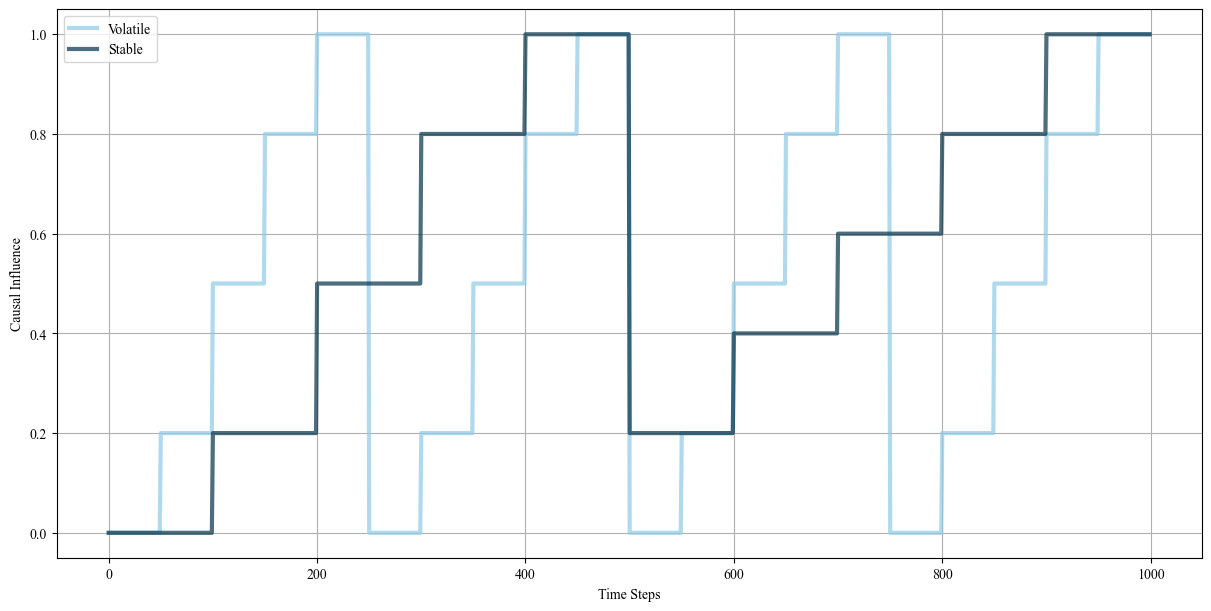

In [26]:
n_samples = 1000
# Define contingencies
dynamic_influences = np.array([0.0, 0.2, 0.5, 0.8, 1.0, 0.0, 0.2, 0.5, 0.8, 1.0, 0.0, 0.2, 0.5, 0.8, 1.0, 0.0, 0.2, 0.5, 0.8, 1.0]).repeat(n_samples / 20)

causal_influences_strong = np.array([0.0, 0.2, 0.5, 0.8, 1.0, 0.2, 0.4, 0.6, 0.8, 1.0]).repeat(
    n_samples / 10)

rcParams['font.family'] = 'Times New Roman'
colors = ["#FB8500", "#219EBC", "#023047", "#FFB703", "#8ECAE6"]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dynamic_influences, label="Volatile", alpha=0.7, linewidth = 3.0, color=colors[4])
plt.plot(causal_influences_strong, label="Stable", alpha=0.7, linewidth = 3.0, color=colors[2])

plt.xlabel("Time Steps")
plt.ylabel("Causal Influence")
plt.legend()
plt.grid()
plt.show()

## Non Causal HGF 
As a baseline, we use a noncausal HGF with two input nodes: One observing the agent's action, and one observing the position of the dynamically evolving state. 

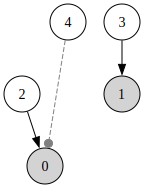

In [ ]:
# Define the continuous HGF
# Generate x_1 and x_2 as a random walk
x1 = np.ones(n_samples) * 2
x2 = np.zeros(n_samples)
input_data = np.array([x1, x2]).T


precision_observation = 2.0
continuous_hgf = (
    Network()
    .add_nodes()
    .add_nodes(precision = precision_observation) 
    .add_nodes(value_children=0)
    .add_nodes(value_children=1)
    .add_nodes(volatility_children=0, mean = 5.0)
)
continuous_hgf.input_data(input_data=input_data);
continuous_hgf.create_belief_propagation_fn()

continuous_hgf.plot_network()



In [8]:
actions = []  # To store agent actions
observations = []  # To store continuous outcomes (sound intensity)
outcomes = [] 
node_0_expected_mean = []
node_1_expected_mean = []
node_2_expected_mean = []
node_3_expected_mean = []
node_0_precision = []
node_1_precision = []
node_2_precision = []
node_3_precision = []
node_0_prediction_error = []
node_1_prediction_error = []
node_2_prediction_error = []
node_3_prediction_error = []
surprise = []

# Get network information
attributes, edges, update_sequence = continuous_hgf.get_network()

for t in range(n_samples):
    precision_action = attributes[4]['mean']
    # 1. Compute action using decision function
    if t == 0:
        action = 0
    else:
        # the position belief is taken as the basis for the action chosen
        expected_mean = attributes[1]['expected_mean']
        action = -expected_mean
    actions.append(action)

    # 2. Observe outcome
    if t == 0:  # First trial: random observation
        # The state eveolves as random walk
        outcome = np.random.normal(0, math.sqrt(1/precision_observation))
        observation = outcome  
    else:
        # state evolves based on previous state plus the randomness of the random walk
        causal_precision =  math.sqrt(1/precision_observation) + (causal_influences_strong[t]**2)*math.sqrt(1/precision_action)
        outcome = observations[-1] + np.random.normal(0, causal_precision) 
        observation = outcome + action * causal_influences_strong[t] 
    

    outcomes.append(outcome)
    observations.append(observation)

    # Prepare input for belief propagation
    action_input = action + np.random.normal(action, math.sqrt(1/precision_action))
    input_data = np.array([action_input, observation])
    data = tuple(np.column_stack((input_data, np.ones(input_data.shape, dtype=int))).ravel())

    # Update the probabilistic network
    attributes, _ = beliefs_propagation(
        attributes=attributes,
        inputs=(*data, 1.0),
        update_sequence=update_sequence,
        edges=edges,
        input_idxs=continuous_hgf.input_idxs,
    )

    # Store metrics
    surprise_t = gaussian_surprise(
        x=attributes[1]["mean"],
        expected_mean=attributes[1]["expected_mean"],
        expected_precision=attributes[1]["expected_precision"],
    )
    surprise.append(surprise_t)

    # Store Node 0 metrics
    node_0_expected_mean.append(attributes[0]["expected_mean"])
    node_0_precision.append(attributes[0]["precision"])
    node_0_prediction_error.append(attributes[0]["temp"]["value_prediction_error"])

    # Store Node 1 metrics
    node_1_expected_mean.append(attributes[1]["expected_mean"])
    node_1_precision.append(attributes[1]["precision"])
    node_1_prediction_error.append(attributes[1]["temp"]["value_prediction_error"])

    # Store Node 2 metrics
    node_2_expected_mean.append(attributes[2]["expected_mean"])
    node_2_precision.append(attributes[2]["precision"])
    node_2_prediction_error.append(attributes[2]["temp"]["value_prediction_error"])

    # Store Node 3 metrics
    node_3_expected_mean.append(attributes[3]["expected_mean"])
    node_3_precision.append(attributes[3]["precision"])
    node_3_prediction_error.append(attributes[3]["temp"]["value_prediction_error"])

# Return results as a dictionary
non_causal_results = {
    "actions": np.array(actions),
    "observations": np.array(observations),
    "outcomes": np.array(outcomes),
    "node_0_expected_mean": np.asarray(node_0_expected_mean),
    "node_0_precision": np.asarray(node_0_precision),
    "node_0_prediction_error": np.asarray(node_0_prediction_error),
    "node_1_expected_mean": np.asarray(node_1_expected_mean),
    "node_1_precision": np.asarray(node_1_precision),
    "node_1_prediction_error": np.asarray(node_1_prediction_error),
    "node_2_expected_mean": np.asarray(node_2_expected_mean),
    "node_2_precision": np.asarray(node_2_precision),
    "node_2_prediction_error": np.asarray(node_2_prediction_error),
    "node_3_expected_mean": np.asarray(node_3_expected_mean),
    "node_3_precision": np.asarray(node_3_precision),
    "node_3_prediction_error": np.asarray(node_3_prediction_error),
    "surprise": np.array(surprise),
}


/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_19793/2142706388.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


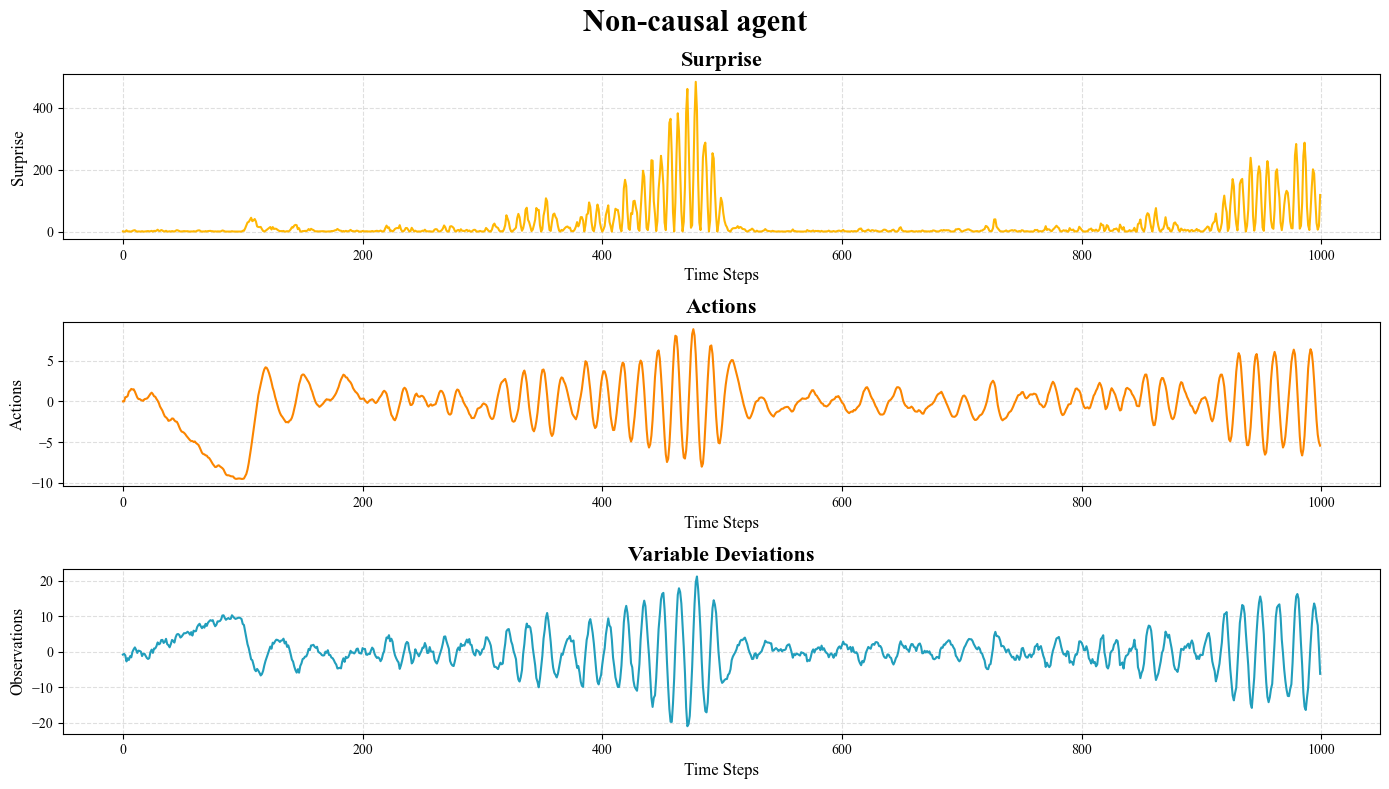

In [9]:

# Plotting - Non-Causal Results (Surprise, Actions, Observations)
fig = plt.figure(figsize=(14, 8))
fig.suptitle('Non-causal agent', fontsize=22, weight='bold')
# Plot surprise
plt.subplot(3, 1, 1)
plt.plot(non_causal_results['surprise'], label='Surprise', color=colors[3], linewidth=1.5)
plt.title("Surprise", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Surprise", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot actions
plt.subplot(3, 1, 2)
plt.plot(non_causal_results['actions'], label='Actions', color=colors[0], linewidth=1.5)
plt.title("Actions", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Actions", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot observations
plt.subplot(3, 1, 3)
plt.plot(non_causal_results['observations'], label='Observations', color=colors[1], linewidth=1.5)
plt.title("Variable Deviations", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Use tight layout for all subplots
plt.tight_layout()
# Display the combined plot
plt.show()

In [10]:
total_suprise_non_causal = sum(non_causal_results['surprise'])
total_actions_non_causal = sum(abs(non_causal_results['actions']))
total_observations_non_causal = sum(abs(non_causal_results['observations']))

print(total_actions_non_causal)
print(total_observations_non_causal)
print(total_suprise_non_causal)

2085.5450750937453
3914.5403457351526
27619.650735020638


## Causal HGF: Inference of the causal action influence
We create another agent, this one with causal coupling between the two input nodes. It is thus infering the causal relationship between actions and outcomes. 
To do so, we first set up the network and edge list accordingly. 

In [11]:
# Define the HGF causal network
hgf_causal = (
    Network()
    .add_nodes()
    .add_nodes(precision = precision_observation) 
    .add_nodes(value_children=0)
    .add_nodes(value_children=1)
    .add_nodes(volatility_children=0, mean = 5.0)
)

# Add causal coupling to Node 0
hgf_causal.attributes[0]["causal_coupling_children"] = jnp.array([0.0])  

# Update the edges variable so it stores the index of the causal child
edges = list(hgf_causal.edges)
adjacency_list = edges[0]

# Create a new adjacency variable for this case
class CausalAdjacencyLists(NamedTuple):
    node_type: int
    value_parents: Optional[Tuple]
    volatility_parents: Optional[Tuple]
    value_children: Optional[Tuple]
    volatility_children: Optional[Tuple]
    coupling_fn: Tuple[Optional[Callable], ...]
    causal_children: Optional[Tuple]


causal_adjacency_list = CausalAdjacencyLists(
    node_type=adjacency_list.node_type,
    value_parents=adjacency_list.value_parents,
    volatility_parents=adjacency_list.volatility_parents,
    value_children=adjacency_list.value_children,
    volatility_children=adjacency_list.volatility_children,
    coupling_fn=adjacency_list.coupling_fn,
    causal_children=(1,),
)

# Insert the new variable back to the edges
edges[0] = causal_adjacency_list
hgf_causal.edges = tuple(edges)

# Add this step at the end of the belief propagation sequence
# Here we simply re-use the previous sequence as template
predictions, updates = continuous_hgf.update_sequence
updates += ((0, continuous_node_causal_strength),)
hgf_causal.update_sequence = (predictions, updates)
hgf_causal = hgf_causal.create_belief_propagation_fn()


### Simluate agent with causal consideration
The agent is using the position belief and the causal coupling belief to inform actions in proportion to the latter. 

In [12]:
actions = []  # To store agent actions
observations = []  # To store continuous outcomes (sound intensity)
outcomes = [] 
causal_strengths = []
node_0_expected_mean = []
node_1_expected_mean = []
node_2_expected_mean = []
node_3_expected_mean = []
node_0_precision = []
node_1_precision = []
node_2_precision = []
node_3_precision = []
node_0_prediction_error = []
node_1_prediction_error = []
node_2_prediction_error = []
node_3_prediction_error = []
surprise = []

# Get network information
attributes, edges, update_sequence = hgf_causal.get_network()

for t in range(n_samples):
    causal_strength = attributes[0]['causal_coupling_children']
    precision_action = attributes[4]['mean']
    
    # 1. Compute action using decision function
    if t == 0:
        action = 0
    else:
        # the position belief is taken as the basis for the action chosen
        expected_mean = attributes[1]['expected_mean']
        if causal_strength[0] > 0.01:
            action = -expected_mean/causal_strength[0]
        else: 
            action = 0.0
    
    actions.append(action)

    # 2. Observe outcome
    if t == 0:  # First trial: random observation
        # The state eveolves as random walk
        outcome = np.random.normal(0, math.sqrt(1/precision_observation))
        observation = outcome  
    else:
        # state evolves based on previous state plus the randomness of the random walk
        causal_precision =  math.sqrt(1/precision_observation) + (causal_influences_strong[t]**2)*math.sqrt(1/precision_action)
        outcome = observations[-1] + np.random.normal(0, causal_precision) 
        observation = outcome + action * causal_influences_strong[t] 
    

    outcomes.append(outcome)
    observations.append(observation)

    # Prepare input for belief propagation
    action_input = action + np.random.normal(action, math.sqrt(1/precision_action))
    input_data = np.array([action_input, observation])
    data = tuple(np.column_stack((input_data, np.ones(input_data.shape, dtype=int))).ravel())

    # Update the probabilistic network
    attributes, _ = beliefs_propagation(
        attributes=attributes,
        inputs=(*data, 1.0),
        update_sequence=update_sequence,
        edges=edges,
        input_idxs=hgf_causal.input_idxs,
    )

    # Store metrics
    surprise_t = gaussian_surprise(
        x=attributes[1]["mean"],
        expected_mean=attributes[1]["expected_mean"],
        expected_precision=attributes[1]["expected_precision"],
    )
    surprise.append(surprise_t)
    causal_strengths.append(attributes[0]["causal_coupling_children"])

    # Store Node 0 metrics
    node_0_expected_mean.append(attributes[0]["expected_mean"])
    node_0_precision.append(attributes[0]["precision"])
    node_0_prediction_error.append(attributes[0]["temp"]["value_prediction_error"])

    # Store Node 1 metrics
    node_1_expected_mean.append(attributes[1]["expected_mean"])
    node_1_precision.append(attributes[1]["precision"])
    node_1_prediction_error.append(attributes[1]["temp"]["value_prediction_error"])

    # Store Node 2 metrics
    node_2_expected_mean.append(attributes[2]["expected_mean"])
    node_2_precision.append(attributes[2]["precision"])
    node_2_prediction_error.append(attributes[2]["temp"]["value_prediction_error"])

    # Store Node 3 metrics
    node_3_expected_mean.append(attributes[3]["expected_mean"])
    node_3_precision.append(attributes[3]["precision"])
    node_3_prediction_error.append(attributes[3]["temp"]["value_prediction_error"])

# Return results as a dictionary
causal_results = {
    "actions": np.array(actions),
    "observations": np.array(observations),
    "outcomes": np.array(outcomes),
    "node_0_expected_mean": np.asarray(node_0_expected_mean),
    "node_0_precision": np.asarray(node_0_precision),
    "node_0_prediction_error": np.asarray(node_0_prediction_error),
    "node_1_expected_mean": np.asarray(node_1_expected_mean),
    "node_1_precision": np.asarray(node_1_precision),
    "node_1_prediction_error": np.asarray(node_1_prediction_error),
    "node_2_expected_mean": np.asarray(node_2_expected_mean),
    "node_2_precision": np.asarray(node_2_precision),
    "node_2_prediction_error": np.asarray(node_2_prediction_error),
    "node_3_expected_mean": np.asarray(node_3_expected_mean),
    "node_3_precision": np.asarray(node_3_precision),
    "node_3_prediction_error": np.asarray(node_3_prediction_error),
    "surprise": np.array(surprise),
    "causal_strengths": np.array(causal_strengths)
}


/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_19793/3962699159.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


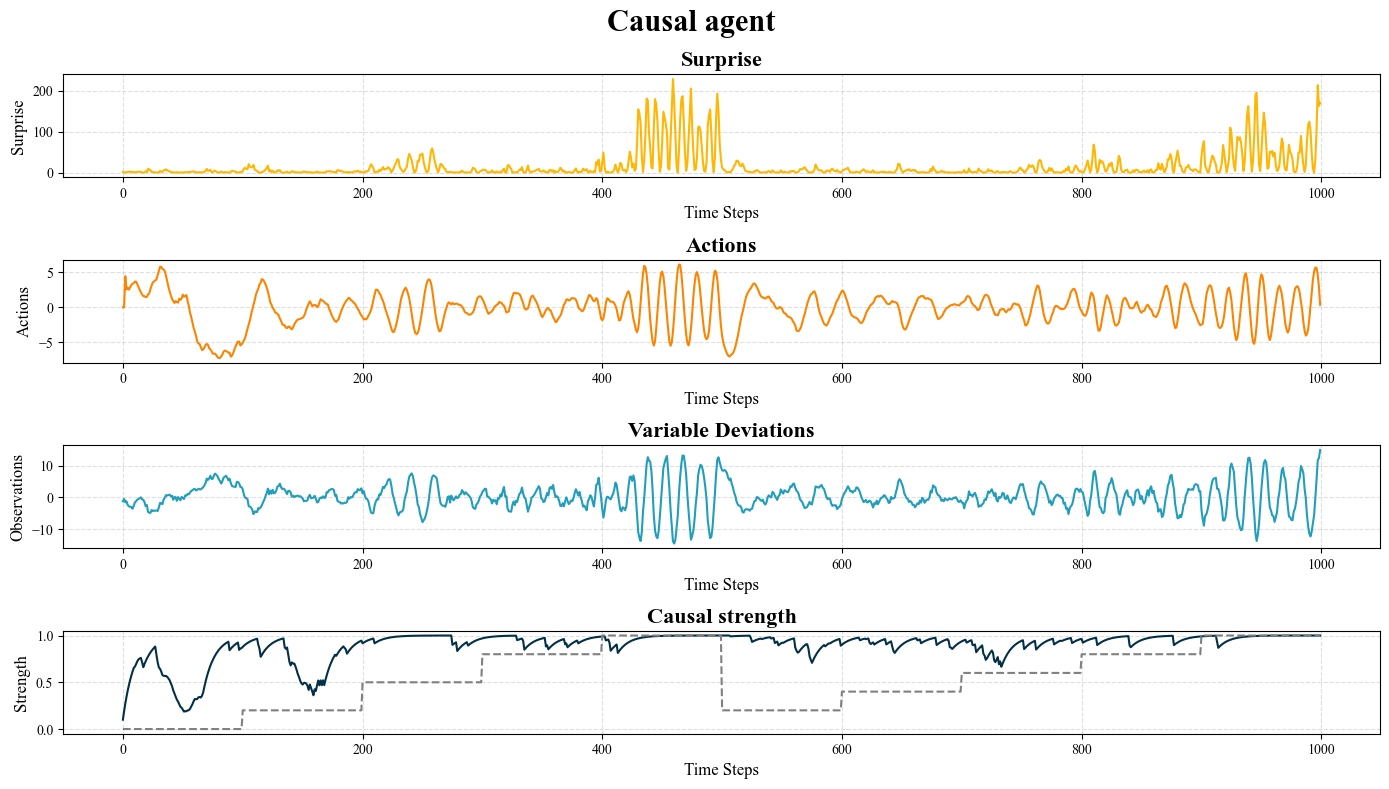

In [ ]:
# Plotting - Causal Results 
fig = plt.figure(figsize=(14, 8))
fig.suptitle('Causal agent ', fontsize=22, weight='bold')
# Plot surprise
plt.subplot(4, 1, 1)
plt.plot(causal_results['surprise'], label='Surprise', color=colors[3], linewidth=1.5)
plt.title("Surprise", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Surprise", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot actions
plt.subplot(4, 1, 2)
plt.plot(causal_results['actions'], label='Actions', color=colors[0], linewidth=1.5)
plt.title("Actions", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Actions", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot observations
plt.subplot(4, 1, 3)
plt.plot(causal_results['observations'], label='Observations', color=colors[1], linewidth=1.5)
plt.title("Variable Deviations", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# PLot strength 
plt.subplot(4, 1, 4)
plt.plot(causal_results['causal_strengths'], label='Inferred', color=colors[2], linewidth=1.5)
plt.title("Causal strength", fontsize=16, weight='bold')
plt.plot(causal_influences_strong, label='Surprise', color='grey', linewidth=1.5, linestyle = '--')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Strength", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Use tight layout for all subplots
plt.tight_layout()
# Display the combined plot
plt.show()

In [14]:
total_suprise_causal = sum(causal_results['surprise'])
total_actions_causal = sum(abs(causal_results['actions']))
total_observations_causal = sum(abs(causal_results['observations']))
total_causal = np.sum(np.abs(causal_results['causal_strengths'].flatten() - causal_influences_strong))

print(total_actions_causal)
print(total_observations_causal)
print(total_suprise_causal)
print(total_causal)


1867.310373293236
3093.870992827825
16787.09732568264
352.33842699974775


### Simulate agent with a different decision making strategy
Similarly as above, but this agent only acts if the inferred strength is below the defined threshold. 

In [15]:
actions = []  # To store agent actions
observations = []  # To store continuous outcomes (sound intensity)
outcomes = [] 
causal_strengths = []
node_0_expected_mean = []
node_1_expected_mean = []
node_2_expected_mean = []
node_3_expected_mean = []
node_0_precision = []
node_1_precision = []
node_2_precision = []
node_3_precision = []
node_0_prediction_error = []
node_1_prediction_error = []
node_2_prediction_error = []
node_3_prediction_error = []
surprise = []

# Get network information
attributes, edges, update_sequence = hgf_causal.get_network()


for t in range(n_samples):
    causal_strength = attributes[0]['causal_coupling_children']
    precision_action = attributes[4]['mean']

    # 1. Compute action using decision function
    if t == 0:
        action = 0
    else:
        # the position belief is taken as the basis for the action chosen
        expected_mean = attributes[1]['expected_mean']
        if 0.85 < causal_strength[0]:  # act only below 0.5 and save guard for devisio
            action = -expected_mean/causal_strength[0]
        else: 
            action = 0
    
    actions.append(action)

    # 2. Observe outcome
    if t == 0:  # First trial: random observation
        # The state eveolves as random walk
        outcome = np.random.normal(0, math.sqrt(1/precision_observation))
        observation = outcome  
    else:
        # state evolves based on previous state plus the randomness of the random walk
        causal_precision =  math.sqrt(1/precision_observation) + (causal_influences_strong[t]**2)*math.sqrt(1/precision_action)
        outcome = observations[-1] + np.random.normal(0, causal_precision) 
        observation = outcome + action * causal_influences_strong[t] 
    

    outcomes.append(outcome)
    observations.append(observation)

    # Prepare input for belief propagation
    action_input = action + np.random.normal(action, math.sqrt(1/precision_action))
    input_data = np.array([action_input, observation])
    data = tuple(np.column_stack((input_data, np.ones(input_data.shape, dtype=int))).ravel())

    # Update the probabilistic network
    attributes, _ = beliefs_propagation(
        attributes=attributes,
        inputs=(*data, 1.0),
        update_sequence=update_sequence,
        edges=edges,
        input_idxs=hgf_causal.input_idxs,
    )

    # Store metrics
    surprise_t = gaussian_surprise(
        x=attributes[1]["mean"],
        expected_mean=attributes[1]["expected_mean"],
        expected_precision=attributes[1]["expected_precision"],
    )
    surprise.append(surprise_t)
    causal_strengths.append(causal_strength)

    # Store Node 0 metrics
    node_0_expected_mean.append(attributes[0]["expected_mean"])
    node_0_precision.append(attributes[0]["precision"])
    node_0_prediction_error.append(attributes[0]["temp"]["value_prediction_error"])

    # Store Node 1 metrics
    node_1_expected_mean.append(attributes[1]["expected_mean"])
    node_1_precision.append(attributes[1]["precision"])
    node_1_prediction_error.append(attributes[1]["temp"]["value_prediction_error"])

    # Store Node 2 metrics
    node_2_expected_mean.append(attributes[2]["expected_mean"])
    node_2_precision.append(attributes[2]["precision"])
    node_2_prediction_error.append(attributes[2]["temp"]["value_prediction_error"])

    # Store Node 3 metrics
    node_3_expected_mean.append(attributes[3]["expected_mean"])
    node_3_precision.append(attributes[3]["precision"])
    node_3_prediction_error.append(attributes[3]["temp"]["value_prediction_error"])

# Return results as a dictionary
causal_results_energy = {
    "actions": np.array(actions),
    "observations": np.array(observations),
    "outcomes": np.array(outcomes),
    "node_0_expected_mean": np.asarray(node_0_expected_mean),
    "node_0_precision": np.asarray(node_0_precision),
    "node_0_prediction_error": np.asarray(node_0_prediction_error),
    "node_1_expected_mean": np.asarray(node_1_expected_mean),
    "node_1_precision": np.asarray(node_1_precision),
    "node_1_prediction_error": np.asarray(node_1_prediction_error),
    "node_2_expected_mean": np.asarray(node_2_expected_mean),
    "node_2_precision": np.asarray(node_2_precision),
    "node_2_prediction_error": np.asarray(node_2_prediction_error),
    "node_3_expected_mean": np.asarray(node_3_expected_mean),
    "node_3_precision": np.asarray(node_3_precision),
    "node_3_prediction_error": np.asarray(node_3_prediction_error),
    "surprise": np.array(surprise),
    "causal_strengths": np.array(causal_strengths)
}


/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_19793/3455870500.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


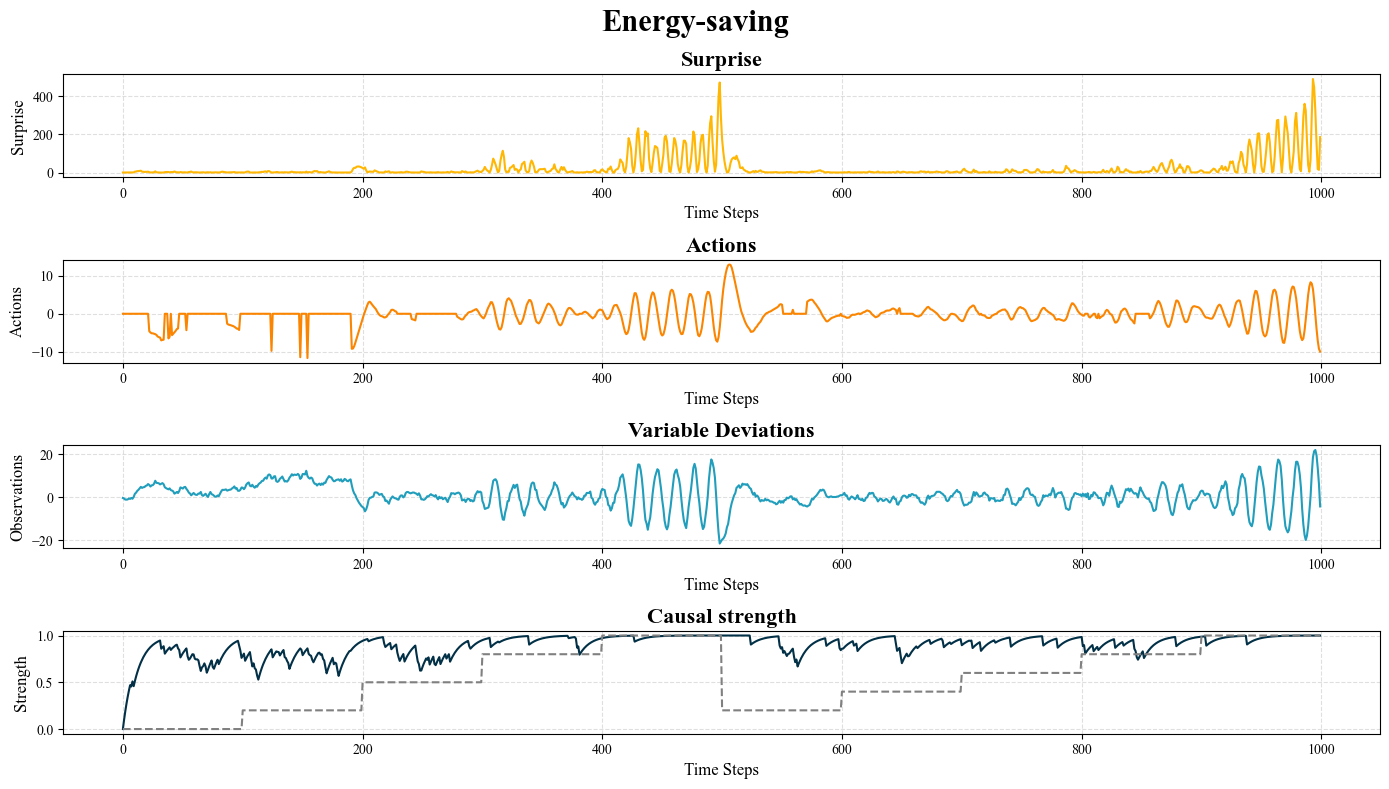

In [ ]:
# Plotting
fig = plt.figure(figsize=(14, 8))
fig.suptitle('Energy-saving', fontsize=22, weight='bold')
# Plot surprise
plt.subplot(4, 1, 1)
plt.plot(causal_results_energy['surprise'], label='Surprise', color=colors[3], linewidth=1.5)
plt.title("Surprise", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Surprise", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot actions
plt.subplot(4, 1, 2)
plt.plot(causal_results_energy['actions'], label='Actions', color=colors[0], linewidth=1.5)
plt.title("Actions", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Actions", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot observations
plt.subplot(4, 1, 3)
plt.plot(causal_results_energy['observations'], label='Observations', color=colors[1], linewidth=1.5)
plt.title("Variable Deviations", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# PLot strength 
plt.subplot(4, 1, 4)
plt.plot(causal_results_energy['causal_strengths'], label='Inferred', color=colors[2], linewidth=1.5)
plt.title("Causal strength", fontsize=16, weight='bold')
plt.plot(causal_influences_strong, label='Surprise', color='grey', linewidth=1.5, linestyle = '--')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Strength", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Use tight layout for all subplots
plt.tight_layout()
# Display the combined plot
plt.show()

In [17]:
total_suprise_energy = np.sum(causal_results_energy['surprise'])
total_actions_energy = np.sum(np.abs(causal_results_energy['actions']))
total_observations_energy = np.sum(np.abs(causal_results_energy['observations']))
total_causal_energy = np.sum(np.abs(causal_results_energy['causal_strengths'].flatten() - causal_influences_strong))


print(total_actions_energy)
print(total_observations_energy)
print(total_suprise_energy)
print(total_causal_energy)




1686.30061078351
4102.300761601677
25131.89
351.83960505276923


### Counterfactual 
Lastly, this agent uses a counterfactual strategy, only acting if the previous action was helpful in reducing deviations from the target state. 

In [18]:
actions = []  # To store agent actions
observations = []  # To store continuous outcomes (sound intensity)
outcomes = [] 
causal_strengths = []
node_0_expected_mean = []
node_1_expected_mean = []
node_2_expected_mean = []
node_3_expected_mean = []
node_0_precision = []
node_1_precision = []
node_2_precision = []
node_3_precision = []
node_0_prediction_error = []
node_1_prediction_error = []
node_2_prediction_error = []
node_3_prediction_error = []
surprise = []

# Get network information
attributes, edges, update_sequence = hgf_causal.get_network()

for t in range(n_samples):
    causal_strength = attributes[0]['causal_coupling_children']
    precision_action = attributes[4]['mean']

    # 1. Compute action using decision function
    if t == 0:
        action = 0
    else:
        # the position belief is taken as the basis for the action chosen
        expected_mean = attributes[1]['expected_mean']
        treshold = 0.5
        if 0.01 < causal_strength[0]:
            # Previous observation and action
            previous_observation = observations[-1]
            previous_action = actions[-1]

            # Compute counterfactual observation without the previous action
            counterfactual_observation = previous_observation - previous_action * causal_influences_strong[-1]

            # Compare deviations from 0
            actual_deviation = abs(previous_observation)
            counterfactual_deviation = abs(counterfactual_observation)

            # Check if the action was effective in reducing deviation from 0
            if counterfactual_deviation < actual_deviation:
                # Previous action did not help; don't act
                action = 0.0
            
            else:
                action = -expected_mean/causal_strength[0]
        else: 
            action = 0.0
    
    actions.append(action)

    # 2. Observe outcome
    if t == 0:  # First trial: random observation
        # The state eveolves as random walk
        outcome = np.random.normal(0, math.sqrt(1/precision_observation))
        observation = outcome  
    else:
        # state evolves based on previous state plus the randomness of the random walk
        causal_precision =  math.sqrt(1/precision_observation) + (causal_influences_strong[t]**2)*math.sqrt(1/precision_action)
        outcome = observations[-1] + np.random.normal(0, causal_precision) 
        observation = outcome + action * causal_influences_strong[t] 
    

    outcomes.append(outcome)
    observations.append(observation)

    # Prepare input for belief propagation
    action_input = action + np.random.normal(action, math.sqrt(1/precision_action))
    input_data = np.array([action_input, observation])
    data = tuple(np.column_stack((input_data, np.ones(input_data.shape, dtype=int))).ravel())

    # Update the probabilistic network
    attributes, _ = beliefs_propagation(
        attributes=attributes,
        inputs=(*data, 1.0),
        update_sequence=update_sequence,
        edges=edges,
        input_idxs=hgf_causal.input_idxs,
    )

    # Store metrics
    surprise_t = gaussian_surprise(
        x=attributes[1]["mean"],
        expected_mean=attributes[1]["expected_mean"],
        expected_precision=attributes[1]["expected_precision"],
    )
    surprise.append(surprise_t)
    causal_strengths.append(attributes[0]["causal_coupling_children"])

    # Store Node 0 metrics
    node_0_expected_mean.append(attributes[0]["expected_mean"])
    node_0_precision.append(attributes[0]["precision"])
    node_0_prediction_error.append(attributes[0]["temp"]["value_prediction_error"])

    # Store Node 1 metrics
    node_1_expected_mean.append(attributes[1]["expected_mean"])
    node_1_precision.append(attributes[1]["precision"])
    node_1_prediction_error.append(attributes[1]["temp"]["value_prediction_error"])

    # Store Node 2 metrics
    node_2_expected_mean.append(attributes[2]["expected_mean"])
    node_2_precision.append(attributes[2]["precision"])
    node_2_prediction_error.append(attributes[2]["temp"]["value_prediction_error"])

    # Store Node 3 metrics
    node_3_expected_mean.append(attributes[3]["expected_mean"])
    node_3_precision.append(attributes[3]["precision"])
    node_3_prediction_error.append(attributes[3]["temp"]["value_prediction_error"])

# Return results as a dictionary
causal_results_counterfactual = {
    "actions": np.array(actions),
    "observations": np.array(observations),
    "outcomes": np.array(outcomes),
    "node_0_expected_mean": np.asarray(node_0_expected_mean),
    "node_0_precision": np.asarray(node_0_precision),
    "node_0_prediction_error": np.asarray(node_0_prediction_error),
    "node_1_expected_mean": np.asarray(node_1_expected_mean),
    "node_1_precision": np.asarray(node_1_precision),
    "node_1_prediction_error": np.asarray(node_1_prediction_error),
    "node_2_expected_mean": np.asarray(node_2_expected_mean),
    "node_2_precision": np.asarray(node_2_precision),
    "node_2_prediction_error": np.asarray(node_2_prediction_error),
    "node_3_expected_mean": np.asarray(node_3_expected_mean),
    "node_3_precision": np.asarray(node_3_precision),
    "node_3_prediction_error": np.asarray(node_3_prediction_error),
    "surprise": np.array(surprise),
    "causal_strengths": np.array(causal_strengths)
}


/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_19793/142744953.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


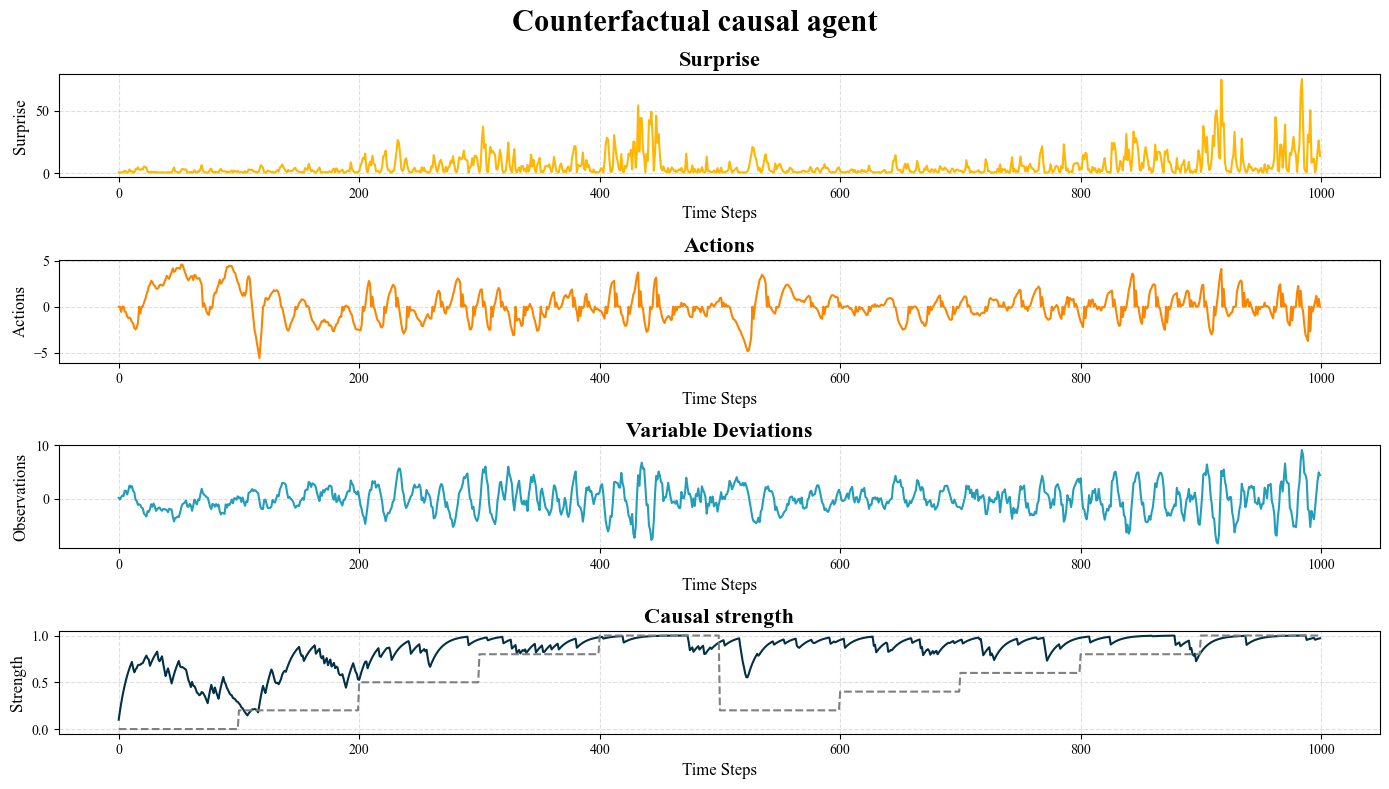

In [19]:

fig = plt.figure(figsize=(14, 8))
fig.suptitle('Counterfactual causal agent', fontsize=22, weight='bold')
# Plot surprise
plt.subplot(4, 1, 1)
plt.plot(causal_results_counterfactual['surprise'], label='Surprise', color=colors[3], linewidth=1.5)
plt.title("Surprise", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Surprise", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot actions
plt.subplot(4, 1, 2)
plt.plot(causal_results_counterfactual['actions'], label='Actions', color=colors[0], linewidth=1.5)
plt.title("Actions", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Actions", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot observations
plt.subplot(4, 1, 3)
plt.plot(causal_results_counterfactual['observations'], label='Observations', color=colors[1], linewidth=1.5)
plt.title("Variable Deviations", fontsize=16, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# PLot strength 
plt.subplot(4, 1, 4)
plt.plot(causal_results_counterfactual['causal_strengths'], label='Inferred', color=colors[2], linewidth=1.5)
plt.title("Causal strength", fontsize=16, weight='bold')
plt.plot(causal_influences_strong, label='Surprise', color='grey', linewidth=1.5, linestyle = '--')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Strength", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Use tight layout for all subplots
plt.tight_layout()
# Display the combined plot
plt.show()

In [20]:
total_suprise_counterfactual = sum(causal_results_counterfactual['surprise'])
total_actions_counterfactual = sum(abs(causal_results_counterfactual['actions']))
total_observations_counterfactual = sum(abs(causal_results_counterfactual['observations']))

print(total_actions_counterfactual)
print(total_observations_counterfactual)
print(total_suprise_counterfactual)
total_causal_counterfactual = np.sum(np.abs(causal_results_counterfactual['causal_strengths'].flatten() - causal_influences_strong))
print(total_causal_counterfactual)

1123.5757105340017
1954.168819516578
6056.502703666687
312.3282058224082


## Comparison of different strategies in their causal discovery
How does the effect of different strategies influence the ability to infer the couplig strength? We plot the inferred strengths below. 

/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_19793/1280994180.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


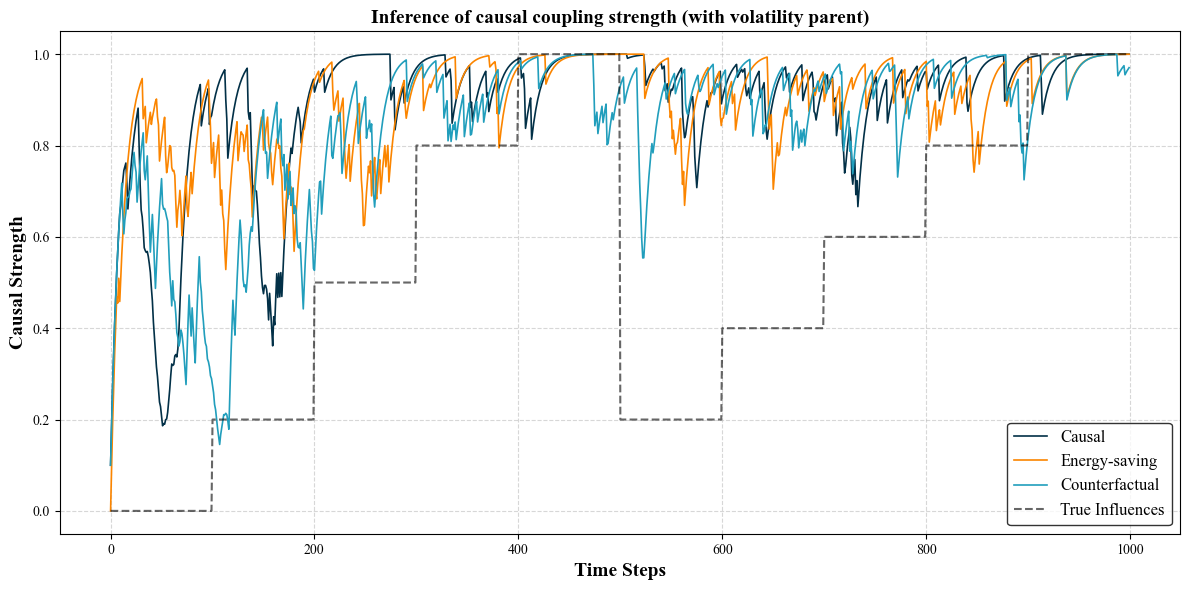

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(causal_results['causal_strengths'], label='Causal', color=colors[2], linewidth=1.2)
plt.plot(causal_results_energy['causal_strengths'], label='Energy-saving', color=colors[0], linewidth=1.2)
plt.plot(causal_results_counterfactual['causal_strengths'], label='Counterfactual', color=colors[1], linewidth=1.2)
plt.plot(causal_influences_strong, label='True Influences', color='black', linestyle='--', linewidth=1.5, alpha=0.6)

# Add a bold title with larger font size
plt.title("Inference of causal coupling strength (with volatility parent)", fontsize=14, weight='bold')

# Add axis labels with a slightly larger font size
plt.xlabel("Time Steps", fontsize=14, weight='bold')
plt.ylabel("Causal Strength", fontsize=14, weight='bold')

# Customize the legend
plt.legend(fontsize=12, frameon=True, loc='best', edgecolor='black')

# Add gridlines with a higher alpha for better visibility
plt.grid(alpha=0.5, linestyle='--')

# Use tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


# Simulation for inference of causal strength
In comparisong to above, the inference here is done without the volatility parent. As seen below, this enhances the inference but leads to reduced stability in the control task. 

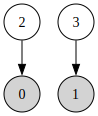

In [1592]:
noncausal_hgf = (
    Network()
    .add_nodes()
    .add_nodes() 
    .add_nodes(value_children=0)
    .add_nodes(value_children=1)
)

noncausal_hgf.input_data(input_data=input_data);
noncausal_hgf.create_belief_propagation_fn()

noncausal_hgf.plot_network()

In [1599]:
def simulate_causal_agent(n_samples, causal_influences, precision_observation, precision_action):
    """
    Simulate an agent's actions and observations under varying causal influences.

    Parameters:
    - n_samples: int, number of time steps to simulate.
    - causal_influences: np.ndarray, vector of causal influences over time.
    - precision_observation: float, precision of the observation.
    - precision_observation: float, precision of the ction.
    - hgf_causal: Network. 

    Returns:
    - dict: Results including actions, observations, outcomes, node metrics, and surprise.
    """
    # Initialize storage
    actions = []
    observations = []
    outcomes = []
    causal_strengths = []
    node_0_expected_mean = []
    node_1_expected_mean = []
    node_2_expected_mean = []
    node_3_expected_mean = []
    node_0_precision = []
    node_1_precision = []
    node_2_precision = []
    node_3_precision = []
    node_0_prediction_error = []
    node_1_prediction_error = []
    node_2_prediction_error = []
    node_3_prediction_error = []
    surprise = []

    # Get network information


    # Define the HGF causal network
    hgf_causal = (
        Network()
        .add_nodes(precision = precision_action)
        .add_nodes(precision = precision_observation) 
        .add_nodes(value_children=0)
        .add_nodes(value_children=1))

    # Add causal coupling to Node 0
    hgf_causal.attributes[0]["causal_coupling_children"] = jnp.array([0.0])  

    # Update the edges variable so it stores the index of the causal child
    edges = list(hgf_causal.edges)
    adjacency_list = edges[0]

    # Create a new adjacency variable for this case
    class CausalAdjacencyLists(NamedTuple):
        node_type: int
        value_parents: Optional[Tuple]
        volatility_parents: Optional[Tuple]
        value_children: Optional[Tuple]
        volatility_children: Optional[Tuple]
        coupling_fn: Tuple[Optional[Callable], ...]
        causal_children: Optional[Tuple]


    causal_adjacency_list = CausalAdjacencyLists(
        node_type=adjacency_list.node_type,
        value_parents=adjacency_list.value_parents,
        volatility_parents=adjacency_list.volatility_parents,
        value_children=adjacency_list.value_children,
        volatility_children=adjacency_list.volatility_children,
        coupling_fn=adjacency_list.coupling_fn,
        causal_children=(1,),)

    # Insert the new variable back to the edges
    edges[0] = causal_adjacency_list
    hgf_causal.edges = tuple(edges)

    # Add this step at the end of the belief propagation sequence
    # Here we simply re-use the previous sequence as template
    predictions, updates = noncausal_hgf.update_sequence
    updates += ((0, continuous_node_causal_strength),)
    hgf_causal.update_sequence = (predictions, updates)
    hgf_causal = hgf_causal.create_belief_propagation_fn()

    attributes, edges, update_sequence = hgf_causal.get_network()

    for t in range(n_samples):
        causal_strength = attributes[0]['causal_coupling_children']

        # 1. Compute action using decision function
        if t == 0:
            action = 0
        else:
            # Use the position belief as the basis for the action
            expected_mean = attributes[1]['expected_mean']
            if 0.01 < causal_strength[0]: 
                action = -expected_mean / causal_strength[0]
            else:
                action = 0

        actions.append(action)

        # 2. Observe outcome
        if t == 0:  # First trial: random observation
            outcome = np.random.normal(0, math.sqrt(1 / precision_observation))
            observation = outcome
        else:
            causal_precision = math.sqrt(1 / precision_observation) + (causal_influences[t] ** 2) * math.sqrt(1 / precision_action)
            outcome = observations[-1] + np.random.normal(0, causal_precision)
            observation = outcome + action * causal_influences[t]

        outcomes.append(outcome)
        observations.append(observation)

        # Prepare input for belief propagation
        action_input = action + np.random.normal(action, math.sqrt(1 / precision_action))
        input_data = np.array([action_input, observation])
        data = tuple(np.column_stack((input_data, np.ones(input_data.shape, dtype=int))).ravel())

        # Update the probabilistic network
        attributes, _ = beliefs_propagation(
            attributes=attributes,
            inputs=(*data, 1.0),
            update_sequence=update_sequence,
            edges=edges,
            input_idxs=hgf_causal.input_idxs,
        )

        # Store metrics
        surprise_t = gaussian_surprise(
            x=attributes[1]["mean"],
            expected_mean=attributes[1]["expected_mean"],
            expected_precision=attributes[1]["expected_precision"],
        )
        surprise.append(surprise_t)
        causal_strengths.append(causal_strength)

        # Store Node 0 metrics
        node_0_expected_mean.append(attributes[0]["expected_mean"])
        node_0_precision.append(attributes[0]["precision"])
        node_0_prediction_error.append(attributes[0]["temp"]["value_prediction_error"])

        # Store Node 1 metrics
        node_1_expected_mean.append(attributes[1]["expected_mean"])
        node_1_precision.append(attributes[1]["precision"])
        node_1_prediction_error.append(attributes[1]["temp"]["value_prediction_error"])

        # Store Node 2 metrics
        node_2_expected_mean.append(attributes[2]["expected_mean"])
        node_2_precision.append(attributes[2]["precision"])
        node_2_prediction_error.append(attributes[2]["temp"]["value_prediction_error"])

        # Store Node 3 metrics
        node_3_expected_mean.append(attributes[3]["expected_mean"])
        node_3_precision.append(attributes[3]["precision"])
        node_3_prediction_error.append(attributes[3]["temp"]["value_prediction_error"])

    # Return results as a dictionary
    return {
        "actions": np.array(actions),
        "observations": np.array(observations),
        "outcomes": np.array(outcomes),
        "node_0_expected_mean": np.asarray(node_0_expected_mean),
        "node_0_precision": np.asarray(node_0_precision),
        "node_0_prediction_error": np.asarray(node_0_prediction_error),
        "node_1_expected_mean": np.asarray(node_1_expected_mean),
        "node_1_precision": np.asarray(node_1_precision),
        "node_1_prediction_error": np.asarray(node_1_prediction_error),
        "node_2_expected_mean": np.asarray(node_2_expected_mean),
        "node_2_precision": np.asarray(node_2_precision),
        "node_2_prediction_error": np.asarray(node_2_prediction_error),
        "node_3_expected_mean": np.asarray(node_3_expected_mean),
        "node_3_precision": np.asarray(node_3_precision),
        "node_3_prediction_error": np.asarray(node_3_prediction_error),
        "surprise": np.array(surprise),
        "causal_strengths": np.array(causal_strengths)
    }

agent_strong_manual = simulate_causal_agent(causal_influences = causal_influences_strong, precision_action= 500.0, precision_observation= 2.0, n_samples=n_samples)
agent_strong_manual_2 = simulate_causal_agent(causal_influences = causal_influences_strong, precision_action= 1000.0, precision_observation= 1.0, n_samples=n_samples)
agent_strong_manual_3 = simulate_causal_agent(causal_influences = causal_influences_strong, precision_action= 10000.0, precision_observation= 1.0, n_samples=n_samples)

agent_shift_manual = simulate_causal_agent(causal_influences = dynamic_influences, precision_action= 500.0, precision_observation= 2.0, n_samples=n_samples)
agent_shift_manual_2 = simulate_causal_agent(causal_influences = dynamic_influences, precision_action= 1000.0, precision_observation= 1.0, n_samples=n_samples)
agent_shift_manual_3 = simulate_causal_agent(causal_influences = dynamic_influences, precision_action= 10000.0, precision_observation= 1.0, n_samples=n_samples)

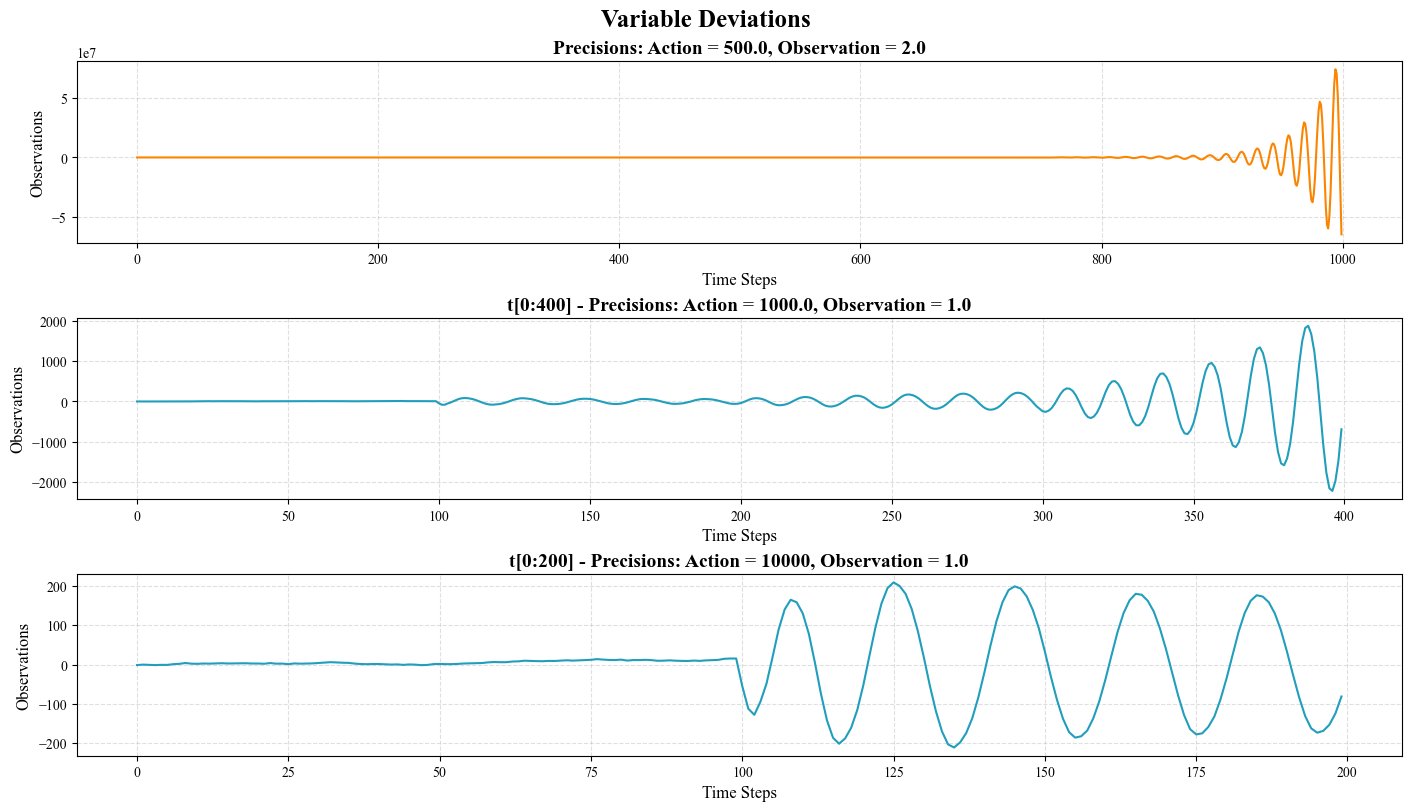

In [1594]:
# Plotting - Non-Causal Results (Surprise, Actions, Observations)
fig = plt.figure(figsize=(14, 8))
fig.suptitle('Variable Deviations', fontsize=18, weight='bold')
# Plot surprise
plt.subplot(3, 1, 1)
plt.plot(agent_strong_manual['observations'], label='Deviations', color=colors[0], linewidth=1.5)
plt.title("Precisions: Action = 500.0, Observation = 2.0", fontsize=14, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot actions
plt.subplot(3, 1, 2)
plt.plot(agent_strong_manual_2['observations'][0:400], label='Deviations', color=colors[1], linewidth=1.5)
plt.title("t[0:400] - Precisions: Action = 1000.0, Observation = 1.0", fontsize=14, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')
# Plot observations
plt.subplot(3, 1, 3)
plt.plot(agent_strong_manual_3['observations'][0:200], label='Deviations', color=colors[1], linewidth=1.5)
plt.title("t[0:200] - Precisions: Action = 10000, Observation = 1.0", fontsize=14, weight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Observations", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')



/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_2481/3524858828.py:35: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 1])  # Leave space for the suptitle


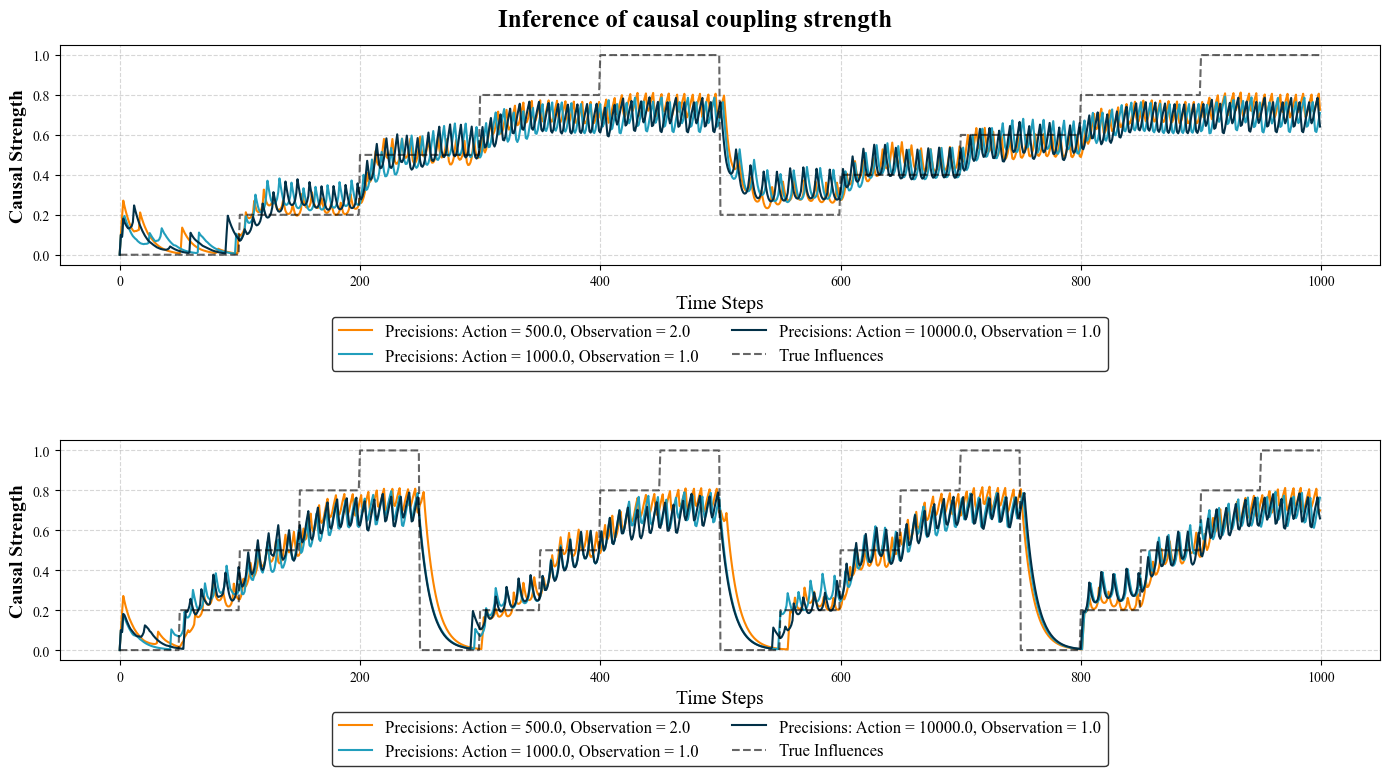

In [1615]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

# Aesthetics
rcParams['font.family'] = 'Times New Roman'
colors = ["#FB8500", "#219EBC", "#023047", "#FFB703", "#8ECAE6"]

# Create a figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 8))  # 2 rows, 1 column

# Add a title to the figure
fig.suptitle('Inference of causal coupling strength', fontsize=18, weight='bold')

# First subplot
axes[0].plot(agent_strong_manual['causal_strengths'], label='Precisions: Action = 500.0, Observation = 2.0', color=colors[0], linewidth=1.5)
axes[0].plot(agent_strong_manual_2['causal_strengths'], label='Precisions: Action = 1000.0, Observation = 1.0', color=colors[1], linewidth=1.5)
axes[0].plot(agent_strong_manual_3['causal_strengths'], label='Precisions: Action = 10000.0, Observation = 1.0', color=colors[2], linewidth=1.5)
axes[0].plot(causal_influences_strong, label='True Influences', color='black', linestyle='--', linewidth=1.5, alpha=0.6)
axes[0].set_xlabel("Time Steps", fontsize=14)
axes[0].set_ylabel("Causal Strength", fontsize=14, weight='bold')
axes[0].legend(fontsize=12, frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, edgecolor='black')
axes[0].grid(alpha=0.5, linestyle='--')

# Second subplot
axes[1].plot(agent_shift_manual['causal_strengths'], label='Precisions: Action = 500.0, Observation = 2.0', color=colors[0], linewidth=1.5)
axes[1].plot(agent_shift_manual_2['causal_strengths'], label='Precisions: Action = 1000.0, Observation = 1.0', color=colors[1], linewidth=1.5)
axes[1].plot(agent_shift_manual_3['causal_strengths'], label='Precisions: Action = 10000.0, Observation = 1.0', color=colors[2], linewidth=1.5)
axes[1].plot(dynamic_influences, label='True Influences', color='black', linestyle='--', linewidth=1.5, alpha=0.6)
axes[1].set_xlabel("Time Steps", fontsize=14)
axes[1].set_ylabel("Causal Strength", fontsize=14, weight='bold')
axes[1].legend(fontsize=12, frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, edgecolor='black')
axes[1].grid(alpha=0.5, linestyle='--')

# Adjust the spacing between subplots
fig.tight_layout(rect=[0, 0, 1, 1])  # Leave space for the suptitle
fig.subplots_adjust(hspace=0.8)  # Increase space between rows

# Show the plot
plt.show()


/var/folders/sr/t35nvgpn1m9d3bl1dbwrj4300000gn/T/ipykernel_2481/1399770419.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


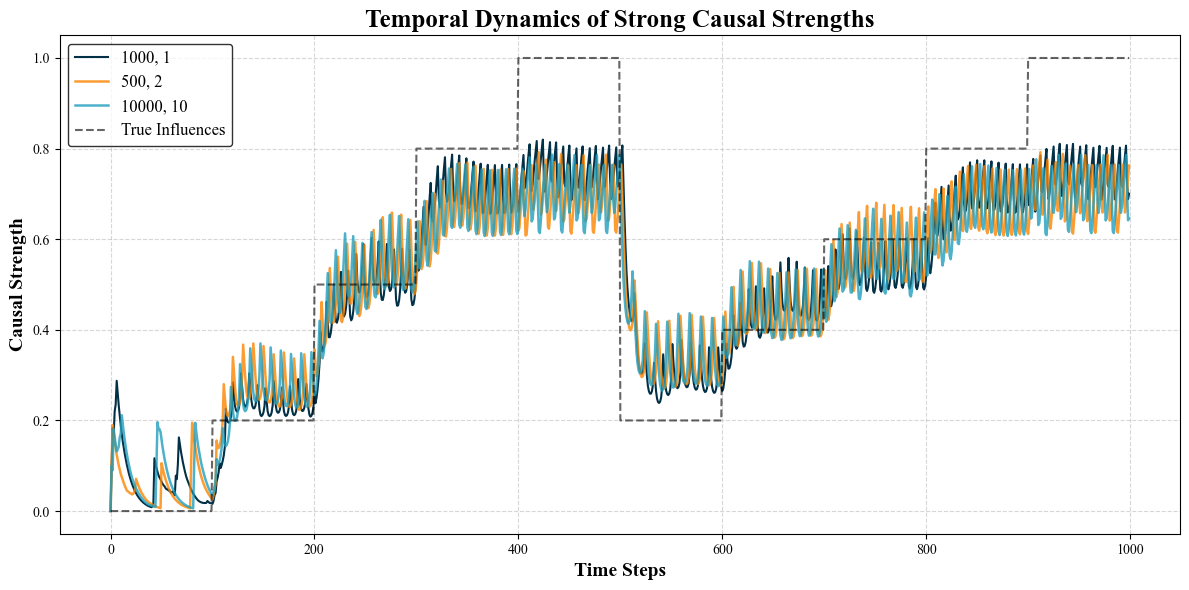

In [1596]:
# aestatitcs
rcParams['font.family'] = 'Times New Roman'
colors = ["#FB8500", "#219EBC", "#023047", "#FFB703", "#8ECAE6"]

plt.figure(figsize=(12, 6))
plt.plot(agent_strong_manual['causal_strengths'], label='1000, 1', color=colors[2], linewidth=1.5)
plt.plot(agent_strong_manual_2['causal_strengths'], label='500, 2', color=colors[0], linewidth=1.8, alpha=0.8)
plt.plot(agent_strong_manual_3['causal_strengths'], label='10000, 10', color=colors[1], linewidth=1.8, alpha=0.8)
plt.plot(causal_influences_strong, label='True Influences', color='black', linestyle='--', linewidth=1.5, alpha=0.6)

# Add a bold title with larger font size
plt.title("Temporal Dynamics of Strong Causal Strengths", fontsize=18, weight='bold')

# Add axis labels with a slightly larger font size
plt.xlabel("Time Steps", fontsize=14, weight='bold')
plt.ylabel("Causal Strength", fontsize=14, weight='bold')

# Customize the legend
plt.legend(fontsize=12, frameon=True, loc='best', edgecolor='black')

# Add gridlines with a higher alpha for better visibility
plt.grid(alpha=0.5, linestyle='--')

# Use tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


For the three simulations without the volatility parent, all agent's infered the strength with high accuracy, also under more volatile conditions.

Since this set up lead to extreme oscilliations of actions and observations as shown above, the volatilty parent was used as introduced in the first simulation of the current notebook, leading to the results of the different decision-making strategies. 


## System configuration

In [1597]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pyhgf,jax,jaxlib

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Wed Jan 01 2025

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 8.29.0

pyhgf : 0.0.0
jax   : 0.4.35
jaxlib: 0.4.35

sklearn   : 1.5.1
pandas    : 2.2.3
seaborn   : 0.13.2
IPython   : 8.29.0
jax       : 0.4.35
matplotlib: 3.9.2
numpy     : 1.26.4
pyhgf     : 0.0.0
sys       : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]

Watermark: 2.5.0

